# Data Exploration

## Authors: Gribaldo Edoardo Silvio, Tichy Vojtech 



## Imports and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
X_train = pd.read_csv('vehicles/vehicles-train.csv', low_memory=False)
X_test = pd.read_csv('vehicles/vehicles-test.csv', low_memory=False)

X_train = X_train.drop_duplicates()
X_test = X_test.drop_duplicates()

y_train = X_train['fuelCost08']
y_test = X_test['fuelCost08']

In [ ]:
print(f"There are {len(X_train)} rows in X_train")
print(f"There are {len(X_test)} rows in X_test")

There are 30000 rows in X_train
There are 7077 rows in X_test


In [ ]:
print(X_train.columns)
print(f"The training dataset contains {len(X_train.columns)} columns.")
print(f"The test dataset contains {len(X_test.columns)} columns.")

Index(['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08',
       'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2',
       'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U',
       'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders',
       'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08',
       'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA',
       'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD',
       'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make',
       'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity',
       'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA',
       'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'guzzler',
       'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA',
       'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr',
       'createdOn', 'modifiedOn

## Data Cleaning

### Finding and handling columns irrelevant to the task

In order to clean the dataset we would like to know the meaning of the features to understand which ones are relevant to our task and which ones are not. \
We looked online and found the column meaning explanation at this link: https://www.fueleconomy.gov/feg/ws/

Some columns have similar names and indicate the same feature (e.g. U at the end of a column name stands for unrounded while at the beginnning of the column name stands for unadjusted) or often there are columns which are derived from other columns and therefore we have to take care of these as well.

Some of these columns have a lot of `nan` values because are for some specific car types (e.g. electric, bi-fuel etc.), so now we only eliminate the ones that are useless for all types of cars, later on we will split the cars by type and drop some more columns.

In [ ]:
# Drop columns related to ids
X_train.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode', 'mpgData'], inplace=True)
X_test.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode', 'mpgData'], inplace=True)

# Drop these columns because they are descriptions of the charger/transmission 
X_train.drop(columns=['c240Dscr', 'c240bDscr', 'trans_dscr'], inplace=True)
X_test.drop(columns=['c240Dscr', 'c240bDscr', 'trans_dscr'], inplace=True)

# Drop these columns because they are combined into comb08
X_train.drop(columns=['highway08', 'city08'], inplace=True)
X_test.drop(columns=['highway08', 'city08'], inplace=True)

# Drop these columns because they are combined into comb08U
X_train.drop(columns=['city08U', 'highway08U'], inplace=True)
X_test.drop(columns=['city08U', 'highway08U'], inplace=True)

# Drop guzzler which is a tax on the fuel emissions but less than 2000 vehicles have this value so it is not useful for the model
X_train.drop(columns=['guzzler'], inplace=True)
X_test.drop(columns=['guzzler'], inplace=True)

# Drop these columns because we have already have the adjusted ones
X_train.drop(columns=['UCity', 'UHighway', 'comb08U'], inplace=True)
X_test.drop(columns=['UCity', 'UHighway', 'comb08U'], inplace=True)

# Drop these columns because are super correlated with the target 
X_train.drop(columns=['co2', 'co2A', 'co2TailpipeGpm', 'barrels08', 'barrelsA08', 'youSaveSpend', 'ghgScore', 'ghgScoreA', 'feScore', 'comb08'], inplace=True)
X_test.drop(columns=['co2', 'co2A', 'co2TailpipeGpm'p, 'barrels08', 'barrelsA08', 'youSaveSpend', 'ghgScore', 'ghgScoreA', 'feScore', 'comb08'], inplace=True)

# Drop the engine description, the model and the make because there are too many unique values
X_train.drop(columns=['eng_dscr'], inplace=True)
X_test.drop(columns=['eng_dscr'], inplace=True)
# X_train.drop(columns=['eng_dscr', 'model', 'make'], inplace=True)
# X_test.drop(columns=['eng_dscr', 'model', 'make'], inplace=True)

# Delete all the columns which have 1 single value in the whole column
X_train = X_train.loc[:, X_train.nunique() > 1]
X_test = X_test.loc[:, X_test.nunique() > 1]

In [ ]:
X_train.describe()

,charge240,cityA08,cityA08U,cityCD,cityE,cityUF,co2TailpipeAGpm,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,fuelCost08,fuelCostA08,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,lv2,lv4,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCityA,UHighwayA,year,charge240b,phevCity,phevHwy,phevComb
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,29891.000000,29894.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.025012,0.616500,0.372864,0.000491,0.202184,0.000760,21.794245,0.690733,0.410354,0.209325,0.000409,0.000742,5.783145,3.336559,1807.021667,98.666667,0.819133,0.480626,0.000292,0.218730,0.000720,1.838100,9.292733,1.768867,6.160033,13.199267,34.381600,0.414967,0.362864,0.040175,0.351890,0.036279,0.770003,1.111066,2002.029433,0.004458,0.075100,0.073233,0.074033
std,0.436744,4.073481,3.723304,0.044698,3.042655,0.020367,104.032037,4.221234,3.775767,3.133487,0.039586,0.019905,1.755709,1.340839,485.410445,469.912314,4.606488,4.019322,0.033203,3.266577,0.019383,5.752095,26.828164,4.316318,9.552842,30.678842,46.276036,8.307338,8.056707,1.227417,8.160266,1.090742,5.600373,6.473490,9.839959,0.144984,2.064672,1.951716,2.003552
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,550.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1984.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.200000,1450.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1995.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,1800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.300000,2050.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,91.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2010.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,127.000000,127.093000,5.350000,122.000000,0.849000,719.000000,117.000000,116.936400,121.000000,4.800000,0.834000,16.000000,8.400000,5550.000000,3900.000000,107.000000,106.531000,4.060000,120.000000,0.813000,49.000000,124.000000,41.000000,55.000000,194.000000,192.000000,294.000000,285.700000,77.504000,303.200000,65.632000,181.560900,152.187800,2017.000000,7.000000,97.000000,79.000000,88.000000


### HeatMap 

The correlation heatmap helps us to determine, which columns are possible candidates for dropping. At first glance, there is quite a lot of strong correlations for us to look at.

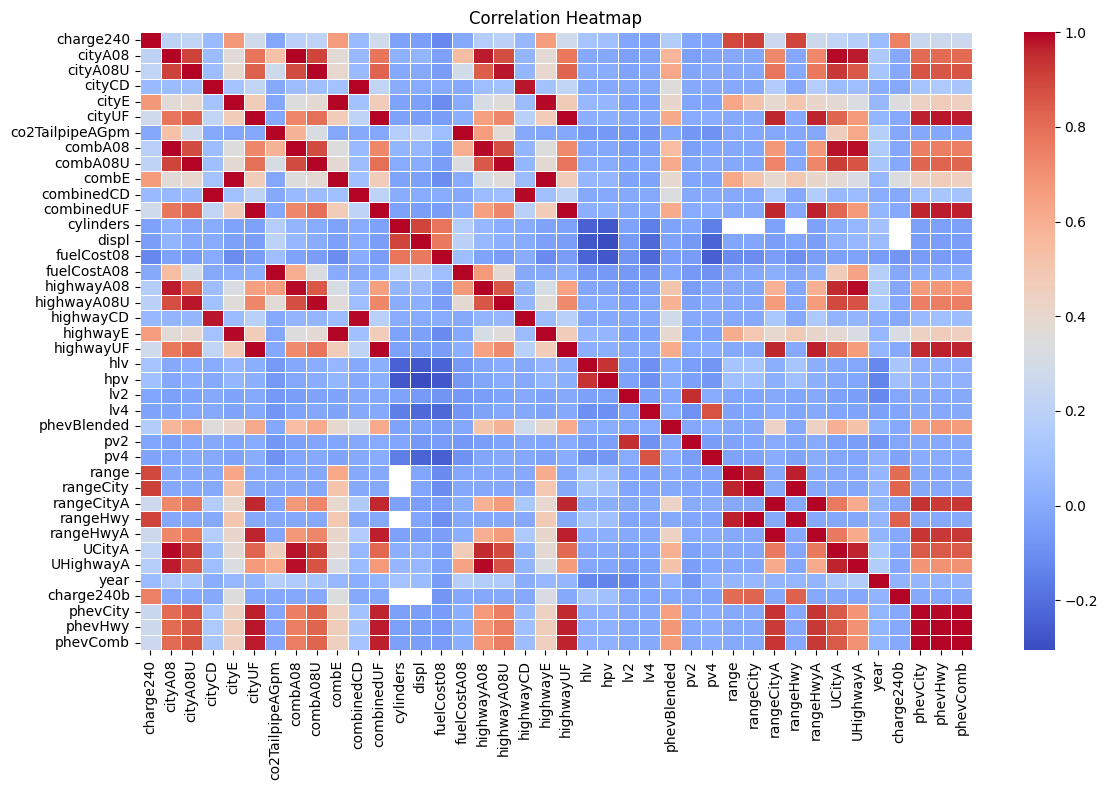

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(numeric_only=True), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### StartStop 

It is a relatively recent invention (manufacturers started to use it around 2012, while it is much more used in the last 10 years) so if the value is `NaN`, we assume the value of `False`.

In [ ]:
mapping_dict = {'Y': 1, 'N': 0, 'y': 1, 'n': 0}

X_train['startStop'] = X_train['startStop'].map(mapping_dict)
X_test['startStop'] = X_test['startStop'].map(mapping_dict)

X_train['startStop'] = X_train['startStop'].fillna(0)
X_test['startStop'] = X_test['startStop'].fillna(0)

print(X_train['startStop'].value_counts(dropna=False))

startStop
0.0    28654
1.0     1346
Name: count, dtype: int64


### Volume

We leave the function we have created to derive the total interior volume but in the model we preferred to use the `VClass` because the volume has too many void (0) entries, whilst the `VClass` column has no missing values.

In [ ]:
def compute_interior_volume(df: pd.DataFrame) -> pd.DataFrame:
	"""
	@brief compute the total interior volume of a car out of all accessible columns and drop columns 
		   which will no longer be used in this context
		   
		   dropped columns: hpv, pv2, pv4, hlv, lv2, lv4
		   temp columns: passenger_volume, luggage_volume
		   new column: total_interior_volume

	@param df input dataframe
	@return dataframe with reduced columns
	"""
	df['passenger_volume'] = df['hpv'] + df['pv2'] + df['pv4']

	df['luggage_volume'] = df['hlv'] + df['lv2'] + df['lv4']

	df['total_interior_volume'] = df['passenger_volume'] + df['luggage_volume']

	volume_cols_to_drop = ['hpv', 'pv2', 'pv4', 'hlv', 'lv2', 'lv4', 'passenger_volume', 'luggage_volume']

	df.drop(columns=volume_cols_to_drop, inplace=True)
	
	return df

X_train = compute_interior_volume(X_train)
X_test = compute_interior_volume(X_test)

total_interior_volume
0      13693
110      575
105      485
100      481
103      467
111      462
101      462
113      420
116      389
102      357
114      355
104      345
96       336
97       330
112      313
115      285
93       284
122      280
120      276
75       261
99       251
109      249
108      248
119      246
125      245
118      238
106      237
121      224
117      220
107      197
126      193
123      188
86       184
98       180
94       176
124      172
73       163
88       162
83       157
92       154
95       151
89       148
132      146
129      145
130      139
90       134
134      122
128      112
82       112
131      106
205      105
221      104
133       88
127       83
91        79
206       79
204       78
227       76
140       76
87        76
136       76
84        75
139       73
202       72
137       68
181       67
183       62
208       62
225       61
199       59
143       59
216       58
135       57
197       56
187       55
80 

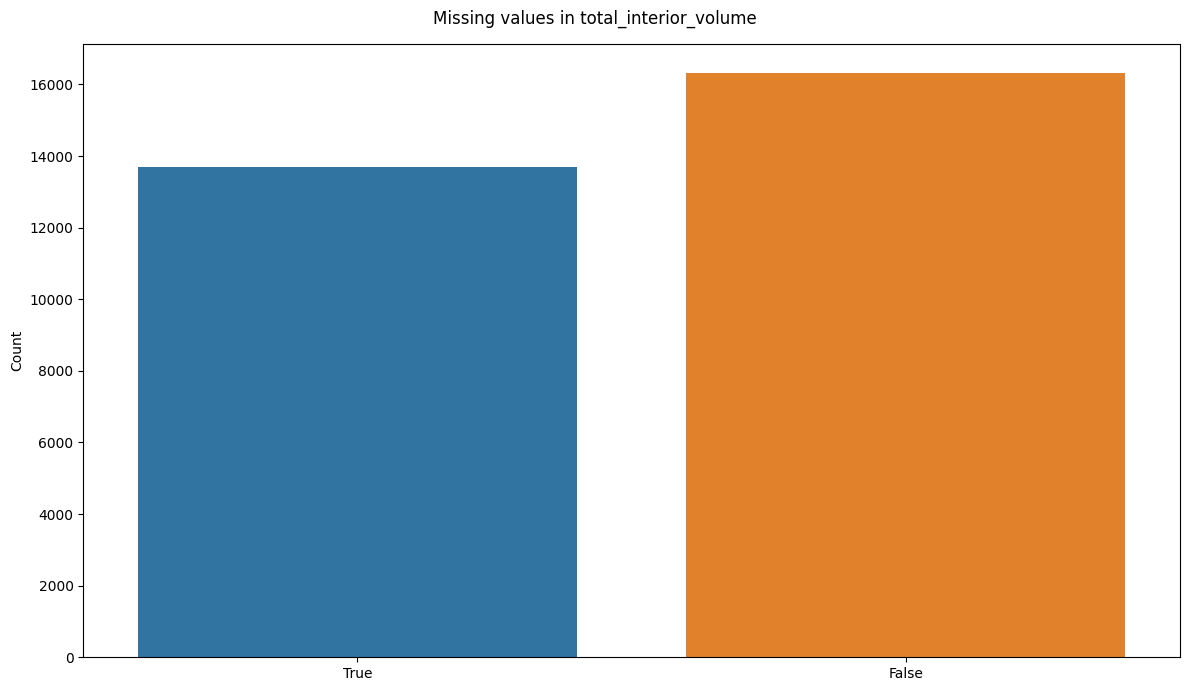

In [ ]:
print(X_train['total_interior_volume'].value_counts(dropna=False))

missing_interior_values = np.where(X_train['total_interior_volume'] == 0, "True", "False")

plt.figure(figsize=(7,7))
sns.countplot(x=missing_interior_values, hue=missing_interior_values, palette="viridis")
plt.suptitle("Missing values in total_interior_volume")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Now let's handle some more difficult columns

In [11]:
X_train['trany'].value_counts(dropna=False)

trany
Automatic 4-spd                     8506
Manual 5-spd                        5835
Automatic (S6)                      2475
Manual 6-spd                        2319
Automatic 5-spd                     2180
Automatic 3-spd                     1845
Automatic 6-spd                     1354
Manual 4-spd                         875
Automatic (S5)                       822
Automatic (S8)                       776
Automatic (variable gear ratios)     639
Automatic 7-spd                      630
Automatic (S7)                       230
Automatic (S4)                       225
Auto(AM-S7)                          207
Automatic 8-spd                      202
Auto(AV-S6)                          135
Auto(AM7)                            123
Auto(AM6)                            103
Automatic (A1)                        95
Auto(AM-S6)                           82
Manual 7-spd                          56
Manual 3-spd                          55
Automatic 9-spd                       55
Auto(AV-S7

### Transmission

In [12]:
def handle_transmission(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Handles the transmission attribute. This column is split into three:
        1. bool column whether the transmission is automatic or manual
        2. number of gears (CVTs have variable gear ratios, will be handled later)
        3. bool column whether the transmission is a CVT
    @param df input dataframe
    @return transformed dataframe
    """
    is_manual = df['trany'].str.contains('manual', case=False, na=False)
    is_cvt = df['trany'].str.contains(        
        r'AV|variable', case=False, regex=True, na=False
    )

    df['automatic'] = np.select((is_cvt, is_manual), [2, 0], default=1)

    df['numOfGears'] = df['trany'].str.extract(r'(\d+)').astype(float)
    df.loc[is_cvt, 'numOfGears'] = df['numOfGears'].max() + 1  # ← only this line changes 
    
    return df

In [13]:
X_train = handle_transmission(X_train)
X_test = handle_transmission(X_test)

# Fill the cvt in another class with 10 gears (since they have variable gear ratios it's like they had many gears)
X_train['numOfGears'] = X_train['numOfGears'].fillna(10)
print(X_train['numOfGears'].value_counts(dropna=False))
print(X_train['automatic'].value_counts(dropna=False)) 
print(X_test['numOfGears'].value_counts(dropna=False))

numOfGears
4.0     9625
5.0     8852
6.0     6339
3.0     1902
7.0     1248
8.0      987
10.0     880
1.0       96
9.0       71
Name: count, dtype: int64
automatic
1    19971
0     9160
2      869
Name: count, dtype: int64
numOfGears
4.0     3149
5.0     2461
3.0     1328
6.0       65
8.0       34
7.0       19
10.0      17
9.0        3
1.0        1
Name: count, dtype: int64


In [14]:
# Drop the original 'trany' column since we have already extracted all the useful information from it.
X_train.drop(columns=['trany'], inplace=True)
X_test.drop(columns=['trany'], inplace=True)

### Drive

In [15]:
def handle_drive(df: pd.DataFrame) -> pd.DataFrame:
	""" 
	@brief Replace 2WD with FWD or RWD based on other rows with the same car model. 
		   Also reduces duplicit category values.
		   Note: if there is no same model with FWD or RWD, value 2WD then stays the same

	@param df input dataframe
	@return modified dataframe
	"""
	
	drive_mapping = {
    '4-Wheel or All-Wheel Drive' : 'All-Wheel Drive',
    '4-Wheel Drive' : 'All-Wheel Drive',
	}

	df['drive'] = df['drive'].replace(drive_mapping)

	two_wheel_car_list = df[df['drive'] == '2-Wheel Drive']
	two_wheel_car_list = two_wheel_car_list[['make', 'model']].sort_values(['make', 'model'])
	
	for car in two_wheel_car_list.itertuples(index=False):
		model_cars = df[(df['model'].str.contains(car.model, na=False, case=False)) &
							((df['drive'] == 'Rear-Wheel Drive') | (df['drive'] == 'Front-Wheel Drive') | (df['drive'] == '2-Wheel Drive'))]
		model_cars_val_cnt = model_cars.drive.value_counts()
		model_cars = model_cars[model_cars['drive'] == '2-Wheel Drive'].index
		if len(model_cars_val_cnt) == 2:
			df.loc[model_cars, 'drive'] = model_cars_val_cnt.index[0]

	return df

In [16]:
X_train = handle_drive(X_train)
X_test = handle_drive(X_test)
X_train['drive'].value_counts(dropna=False)

drive
Front-Wheel Drive          10332
Rear-Wheel Drive           10274
All-Wheel Drive             7975
NaN                         1189
Part-time 4-Wheel Drive      142
2-Wheel Drive                 88
Name: count, dtype: int64

We would like to distinguish whether a given car is either:
1. Front-Wheel Drive 
2. Rear-Wheel Drive 
3. both Front and Rear Wheel Drive (All wheel Drive)

So for cars with value `2-Wheel Drive` we would like to discover, whether they are type 1. or type 2.
We can also later try to fill the values for `Nan` based on available information found on the internet.

In [17]:
X_train[X_train['drive'] == '2-Wheel Drive'].model.unique()

<StringArray>
[               'RAV4 EV', 'Explorer USPS Electric',              'Truck 2WD',
     'Vandura G15/25 2WD',          'Cargo Van 2WD',    'E150 Club Wagon 2WD',
                'Van 2WD',       'FJ8c Post Office',      'DJ Po Vehicle 2WD',
   'S10 Utility Body 2WD',   'S15 Utility Body 2WD',     'Funeral Coach  2WD',
         'Pathfinder 2WD',           'S10 Electric']
Length: 14, dtype: str

In [18]:
nan_models = X_train.loc[X_train['drive'].isna(), ['model', 'make', 'year']]
print(nan_models)

                             model                           make  year
7138                      Altra EV                         Nissan  2000
8144                         Th!nk                           Ford  2001
8147                    Hyper-Mini                         Nissan  2001
18217           Spider Veloce 2000                     Alfa Romeo  1984
18218                         X1/9                        Bertone  1984
18219                     Corvette                      Chevrolet  1984
18220                     Corvette                      Chevrolet  1984
18221                        300ZX                         Nissan  1984
18222                        300ZX                         Nissan  1984
18223                        300ZX                         Nissan  1984
18224                        300ZX                         Nissan  1984
18225                          EXP                           Ford  1984
18227                          EXP                           For

We go check online which are rear-wheeled and which are front-wheeled.

In [19]:
rwd_cars = [
    'Corvette', '300ZX', 'RX-7', '911 SC', '928 S', '944', 'Starion', 'Conquest', 
    'Spider Veloce', 'Spider Pininfarina', 'X1/9', 'Countach', 'Esprit', 'Avanti II', 
    'Biturbo', 'Quattroporte', 'XJ', 'XJS', '380SL', '500SEC', '500SEL', '300D', 
    '300SD', '300TD', 'Lagonda', 'Saloon', 'Vantage', 'Volante', 'Corniche', 
    'Silver Spirit', 'Camargue', 'Kenyon',
    'Camaro', 'Firebird', 'Mustang', 'Capri', 'Thunderbird', 'Cougar', 'Grand Prix', 
    'Monte Carlo', 'Regal', 'Cutlass Supreme', 'Bonneville', 'Diplomat', 'Gran Fury', 
    'Newport', 'Fifth Avenue', 'LTD Crown Victoria', 'Grand Marquis', 'Town Car', 
    'Impala', 'Caprice', 'Parisienne', 'Delta 88', 'Ninety-Eight', 'LeSabre',
    'Fiero', 'Hyper-Mini'
    'Truck 2WD', 'Vandura G15/25 2WD', 'Cargo Van 2WD', 'E150 Club Wagon 2WD', 
    'Van 2WD', 'FJ8c Post Office', 'DJ Po Vehicle 2WD', 'S10 Utility Body 2WD', 
    'S15 Utility Body 2WD', 'Funeral Coach  2WD'
]

fwd_cars = [
    'Civic', 'Accord', 'Prelude', 'CRX', 'Sentra', 'Maxima', 'Stanza', 'Pulsar', 
    'Camry', 'Corolla', 'Tercel', 'Starlet', 'GLC', '626', 'Cordia', 'Tredia', 
    'Colt', 'Precis', 'I-Mark', 'Impulse', 'Rabbit', 'Jetta', 'Scirocco', 'Quantum', 
    '4000', '5000S', 'Coupe GT', '900', '18i', 'Fuego', 'Alliance', 'Encore', '505', '604',
    'Cavalier', 'Celebrity', 'Citation II', 'Skyhawk', 'Skylark', 'Century', 'Firenza', 
    'Omega', 'Phoenix', '6000', 'Cimarron', 'Eldorado', 'Seville', 'Riviera', 'Toronado',
    'Aries', 'Reliant', 'LeBaron', 'Daytona', 'Laser', 'Charger', 'Turismo', 'Omni', 
    'Horizon', '600', 'Tempo', 'Topaz', 'Escort', 'Lynx', 'EXP', 'LTD', 'Marquis',
    'Altra EV', 'Th!nk',
    'RAV4 EV', 'Explorer USPS Electric', 'Pathfinder 2WD', 'S10 Electric'

]

In [20]:
X_train.loc[X_train['model'].str.contains('quattro|4WD', case=False, na=False), ['fwd', 'rwd']] = 1

X_train['is_front'] = np.where(
    X_train['drive'].str.contains('Front|All|4-Wheel|Part', case=False, na=False) |
    (X_train['drive'].eq('2-Wheel Drive') & X_train['model'].isin(fwd_cars)),
    1, 0
)
X_test['is_front'] = np.where(
    X_test['drive'].str.contains('Front|All|4-Wheel|Part', case=False, na=False) |
    (X_test['drive'].eq('2-Wheel Drive') & X_test['model'].isin(fwd_cars)),
    1, 0
)       

X_train['is_rear'] = np.where(
    X_train['drive'].str.contains('Rear|All|4-Wheel|Part', case=False, na=False) |
    (X_train['drive'].eq('2-Wheel Drive') & ~X_train['model'].isin(rwd_cars)),
    1, 0
)

X_test['is_rear'] = np.where(
    X_test['drive'].str.contains('Rear|All|4-Wheel|Part', case=False, na=False) |
    (X_test['drive'].eq('2-Wheel Drive') & ~X_test['model'].isin(rwd_cars)),        
    1, 0
)

In [21]:
# Drop the original 'drive' column since we have already extracted all the useful information from it
X_train.drop(columns=['drive'], inplace=True)
X_test.drop(columns=['drive'], inplace=True)

### Size

Here we utilize the `VClass` attribute to determine how big each of the cars is. The advantage of this column is, that it does not have any `NaN` values, the tradeoff here is that it contains a huge number of values and some of the values categories are based on the size of the vehicle while some categories are based on the weight of the vehicle. So first things first, we need to reduce the number of values.

In [22]:
print(X_train['VClass'].value_counts(dropna=False))
print(len(X_train['VClass'].value_counts(dropna=False)))

VClass
Compact Cars                          4405
Midsize Cars                          3551
Subcompact Cars                       3505
Sport Utility Vehicle - 4WD           2090
Sport Utility Vehicle - 2WD           1627
Large Cars                            1612
Two Seaters                           1547
Small Station Wagons                  1215
Standard Pickup Trucks 2WD            1153
Standard Pickup Trucks                1077
Minicompact Cars                      1067
Standard Pickup Trucks 4WD             954
Special Purpose Vehicles               869
Vans                                   520
Midsize Station Wagons                 517
Vans, Cargo Type                       438
Small Pickup Trucks 2WD                420
Small Sport Utility Vehicle 4WD        420
Midsize-Large Station Wagons           363
Special Purpose Vehicle 2WD            360
Standard Sport Utility Vehicle 4WD     346
Small Sport Utility Vehicle 2WD        332
Minivan - 2WD                          331
Vans

In [23]:
def encode_vclass(df: pd.DataFrame) -> pd.DataFrame:
    """
    Evaluates the VClass column and maps it to an ordinal size/utility 
    scale (1-7) optimized for fuel economy prediction.
    """
    # Create the text series to keep the conditions clean
    v = df['VClass'].fillna('')
    
    conditions = [
        # Small Cars 
        v.str.contains('Two Seater|Minicompact|Subcompact', case=False, regex=True),
        
        # Standard Cars & Small Wagons
        v.str.contains('Compact|Mid-Size Cars|Large Cars|Small Station', case=False, regex=True) & ~v.str.contains('Wagons-', case=False),
        
        # Mid to Large Wagons
        v.str.contains('Mid-Size Cars Station|Large Cars Station', case=False, regex=True),
        
        # Small Utility (Light trucks/SUVs)
        v.str.contains('Small Sport Utility|Small Pickup', case=False, regex=True),
        
        # Standard Utility (Mid-weight)
        v.str.contains('Standard Sport Utility|Minivan', case=False, regex=True),
        
        # Heavy Duty 
        v.str.contains('Standard Pickup|Cargo Van|Passenger Van|Van', case=False, regex=True) & ~v.str.contains('Minivan', case=False),
        
        # Special Purpose
        v.str.contains('Special Purpose', case=False, regex=True)
    ]

    choices = [1, 2, 3, 4, 5, 6, 7]

    df['size'] = np.select(conditions, choices, default=4)
    
    df.drop(columns=['VClass'], inplace=True)
    
    return df

In [24]:
X_train = encode_vclass(X_train)
X_test = encode_vclass(X_test)

### FuelType

This column had basically the same problems as `Size`. So we need to apply similar procedure.

In [25]:
def handleFuelType(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief simplifies 'fuelType' attribute by reducing the overall number of values the attribute can have,
           adds a new column 'premium' which says, whether premium fuel was used or not
           fills all missing values in 'startStop' column as False

           initially the 'fuelType' can have all of these values:

                Regular
                Premium
                Gasoline or E85
                Diesel
                Premium or E85
                Electricity
                Midgrade
                CNG
                Gasoline or natural gas
                Premium Gas or Electricity
                Premium and Electricity
                Regular Gas and Electricity
                Gasoline or propane
                Regular Gas or Electricity

           this function reduces the possible values to:

                Gas
                Diesel
                Hybrid
                Electric
                CNG
                FFV

           plus introduces 'premium' boolean column.

    @param df input dataframe
    @return transformed dataframe        
    """
    df['premium'] = df['fuelType'].isin(["Premium","Premium or E85","Premium Gas or Electricity","Premium and Electricity"]).astype(int)

     
    df.loc[(df['fuelType'] == 'Regular') | (df['fuelType'] == 'Premium') | (df['fuelType'] == 'Midgrade'), 'fuel'] = 6
    df.loc[df['fuelType'] == 'Diesel', 'fuel'] = 5
    df.loc[df['atvType'] == 'FFV', 'fuel'] = 4
    df.loc[df['fuelType'] == 'CNG', 'fuel'] = 3
    df.loc[(df['fuelType'] == 'Gasoline or natural gas') | (df['fuelType'] == 'Gasoline or propane'), 'fuel'] = 2
    df.loc[(df['atvType'] == 'Hybrid') | (df['atvType'] == 'Plug-in Hybrid'), 'fuel'] = 1
    df.loc[df['atvType'] == 'EV', 'fuel'] = 0
    
    df.drop(columns=['fuelType', 'fuelType1', 'fuelType2', 'atvType'], inplace=True)

    return df

In [26]:
X_train = handleFuelType(X_train)
X_test = handleFuelType(X_test)

In [27]:
X_train['fuel'].value_counts(dropna=False)

fuel
6.0    27220
4.0     1282
5.0      821
1.0      483
0.0      106
3.0       60
2.0       28
Name: count, dtype: int64

In [28]:
gas_cars = X_train[X_train['fuel'] == 6].copy() 
diesel_cars = X_train[X_train['fuel'] == 5].copy()
ffv_cars = X_train[X_train['fuel'] == 4].copy()
cng_cars = X_train[X_train['fuel'] == 3].copy()
bi_cars = X_train[X_train['fuel'] == 2].copy()
hybrid_cars = X_train[(X_train['fuel'] == 1) ].copy()
ev_cars = X_train[X_train['fuel'] == 0].copy()

cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars]

In [29]:
gas_cars = gas_cars.loc[:, gas_cars.nunique() > 1]
gas_cars_test = X_test[X_test['fuel'] == 6].copy()
gas_cars_test = gas_cars_test.loc[:, gas_cars_test.nunique() > 1]

diesel_cars = diesel_cars.loc[:, diesel_cars.nunique() > 1]
diesel_cars_test = X_test[X_test['fuel'] == 5].copy()
diesel_cars_test = diesel_cars_test.loc[:, diesel_cars_test.nunique() > 1]

ffv_cars = ffv_cars.loc[:, ffv_cars.nunique() > 1]
ffv_cars_test = X_test[X_test['fuel'] == 4].copy()
ffv_cars_test = ffv_cars_test.loc[:, ffv_cars_test.nunique() > 1]

cng_cars = cng_cars.loc[:, cng_cars.nunique() > 1]
cng_cars_test = X_test[X_test['fuel'] == 3].copy()
cng_cars_test = cng_cars_test.loc[:, cng_cars_test.nunique() > 1]

bi_cars = bi_cars.loc[:, bi_cars.nunique() > 1]
bi_cars_test = X_test[X_test['fuel'] == 2].copy()
bi_cars_test = bi_cars_test.loc[:, bi_cars_test.nunique() > 1]

hybrid_cars = hybrid_cars.loc[:, hybrid_cars.nunique() > 1]
hybrid_cars_test = X_test[X_test['fuel'] == 1].copy()
hybrid_cars_test = hybrid_cars_test.loc[:, hybrid_cars_test.nunique() > 1]

ev_cars = ev_cars.loc[:, ev_cars.nunique() > 1]
ev_cars_test = X_test[X_test['fuel'] == 0].copy()
ev_cars_test = ev_cars_test.loc[:, ev_cars_test.nunique() > 1]


In [30]:
print(gas_cars.columns)
print(gas_cars_test.columns)

print("1")
print(len(set(gas_cars.columns) & set(gas_cars_test.columns)))
print(len(set(gas_cars.columns)))
print("2")
print(set(gas_cars_test.columns) - set(gas_cars.columns))

Index(['cylinders', 'displ', 'fuelCost08', 'make', 'model', 'year',
       'startStop', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'size', 'premium'],
      dtype='str')
Index(['cylinders', 'displ', 'fuelCost08', 'make', 'model', 'year',
       'startStop', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'size', 'premium'],
      dtype='str')
1
14
14
2
set()


In [31]:
gas_cars.head(5)


,cylinders,displ,fuelCost08,make,model,year,startStop,total_interior_volume,automatic,numOfGears,is_front,is_rear,size,premium
0,4.0,2.0,1550,Alfa Romeo,Spider Veloce 2000,1985,0.0,0,0,5.0,0,1,1,0
1,12.0,4.9,2900,Ferrari,Testarossa,1985,0.0,0,0,5.0,0,1,1,0
2,4.0,2.2,1200,Dodge,Charger,1985,0.0,96,0,5.0,1,0,1,0
3,8.0,5.2,2900,Dodge,B150/B250 Wagon 2WD,1985,0.0,0,1,3.0,0,1,6,0
4,4.0,2.2,2050,Subaru,Legacy AWD Turbo,1993,0.0,104,0,5.0,1,1,2,1


In [32]:
cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars, bi_cars]
cars_names = ['Gas', 'FFV', 'Diesel', 'Hybrid', 'EV', 'Bifuel']

# Print the column counts
for name, car_df in zip(cars_names, cars_types):
    print(f"{len(car_df)} {name} cars with {len(car_df.columns)} columns")

27220 Gas cars with 14 columns
1282 FFV cars with 25 columns
821 Diesel cars with 13 columns
483 Hybrid cars with 40 columns
106 EV cars with 19 columns
28 Bifuel cars with 22 columns


### Cylinders

We fill the NaN values of cylinders with 0 for EV cars

In [33]:
X_train['cylinders'] = X_train['cylinders'].fillna(0)
X_test['cylinders'] = X_test['cylinders'].fillna(0)

## Descriptive Statistics

After cleaning the data properly we can try to extract useful statistics and some insights.

### Plots

One question could be if there is a correlation between the cilinders of the model of a car and its year of manufacturing.

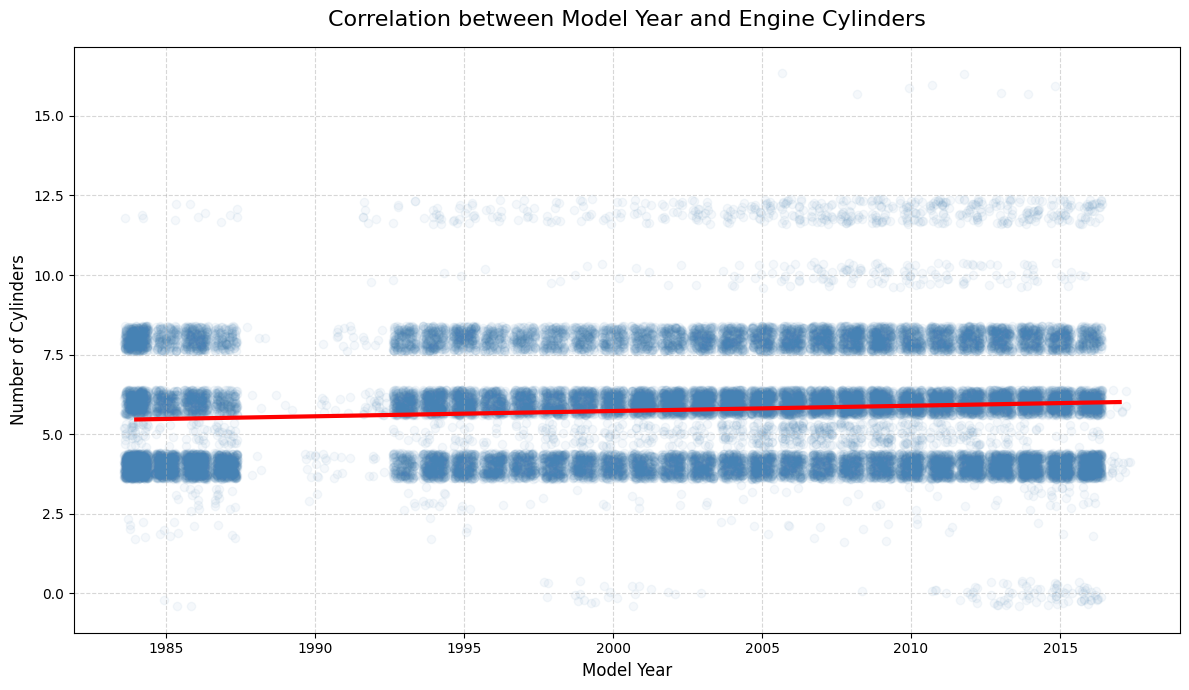

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# regplot calculates and plots a linear regression trendline.
# We add x_jitter and y_jitter to spread out the overlapping points.
sns.regplot(
    data=X_train, 
    x='year', 
    y='cylinders', 
    scatter_kws={'alpha': 0.05, 'color': 'steelblue'}, # Low alpha makes dense areas darker
    line_kws={'color': 'red', 'linewidth': 3},         # Red line shows the correlation trend
    x_jitter=0.4, 
    y_jitter=0.4
)

plt.title('Correlation between Model Year and Engine Cylinders', fontsize=16, pad=15)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Number of Cylinders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

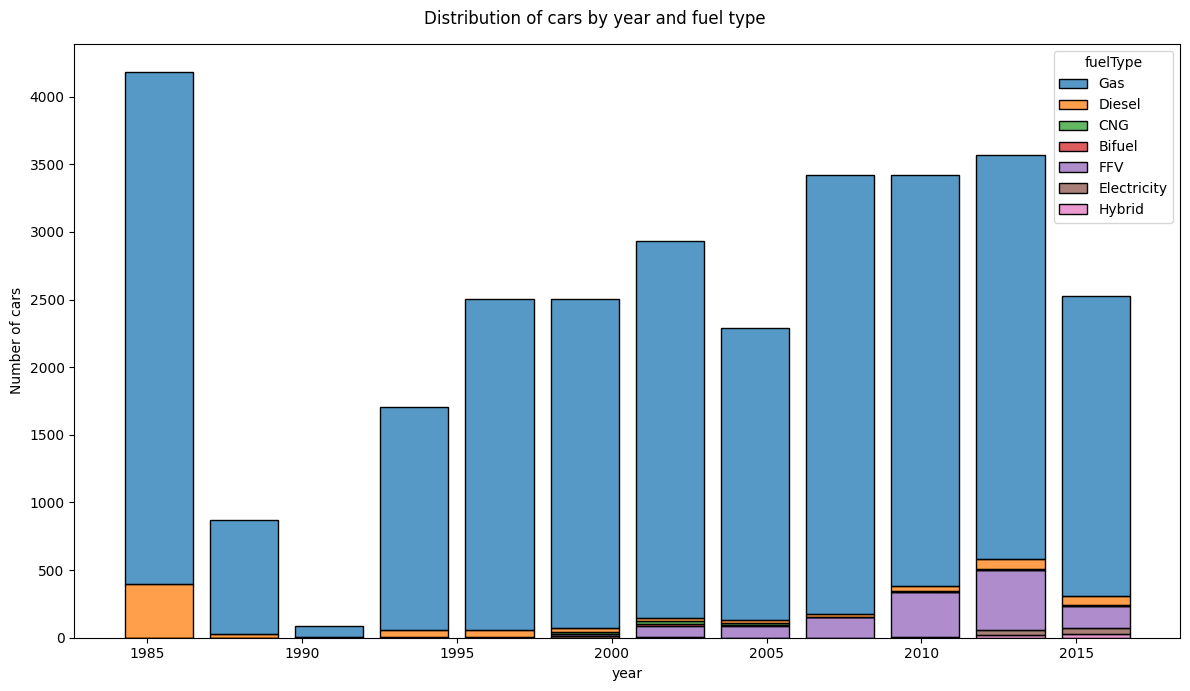

In [109]:
plt.figure(figsize=(12,7))
sns.histplot(data=X_train, x='year', hue='fuelType', bins=12, color="monochromatic", shrink=.8, multiple="stack")
plt.ylabel("Number of cars")
plt.suptitle("Distribution of cars by year and fuel type")

plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = list(X_train.select_dtypes(include=['category', 'object', 'str']).columns)
categorical_cols.remove('model')

plt.subplots(,figsize=(12,7))



['fuelType',
 'fuelType1',
 'make',
 'model',
 'atvType',
 'fuelType2',
 'rangeA',
 'evMotor',
 'numOfGears']

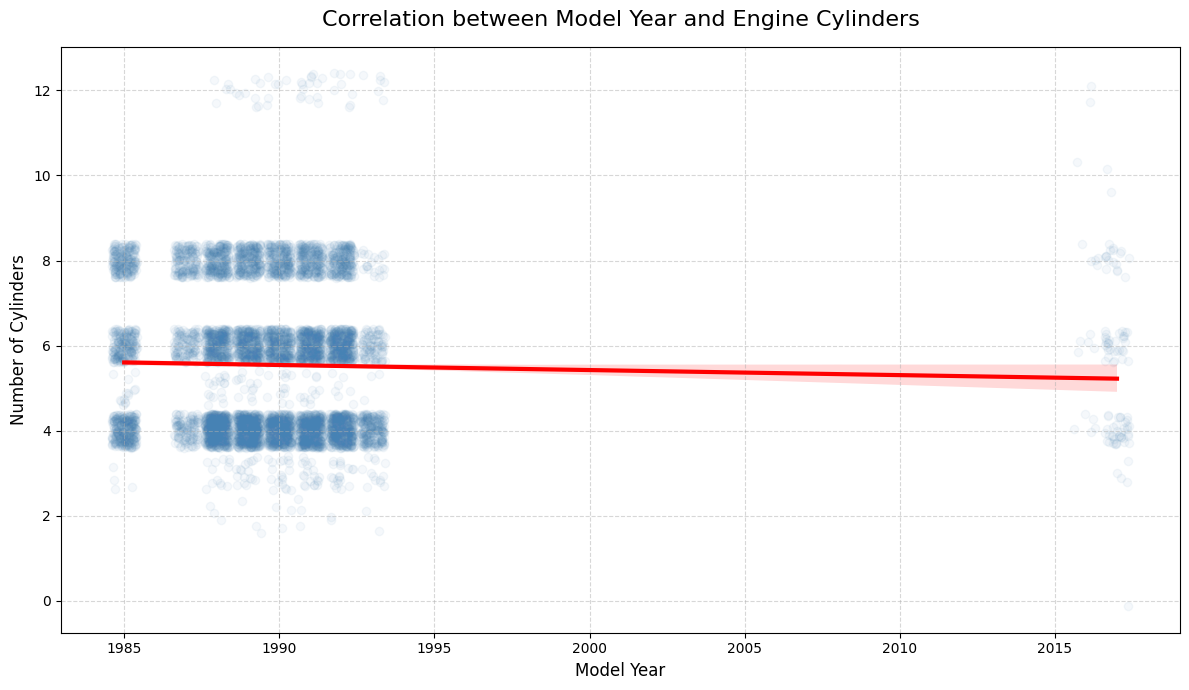

In [ ]:
plt.figure(figsize=(12, 7))

# regplot calculates and plots a linear regression trendline.
# We add x_jitter and y_jitter to spread out the overlapping points.
sns.regplot(
    data=X_test, 
    x='year', 
    y='cylinders', 
    scatter_kws={'alpha': 0.05, 'color': 'steelblue'}, # Low alpha makes dense areas darker
    line_kws={'color': 'red', 'linewidth': 3},         # Red line shows the correlation trend
    x_jitter=0.4, 
    y_jitter=0.4
)

plt.title('Correlation between Model Year and Engine Cylinders', fontsize=16, pad=15)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Number of Cylinders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

in this dataset there seems to be no correlation between years and cylinders

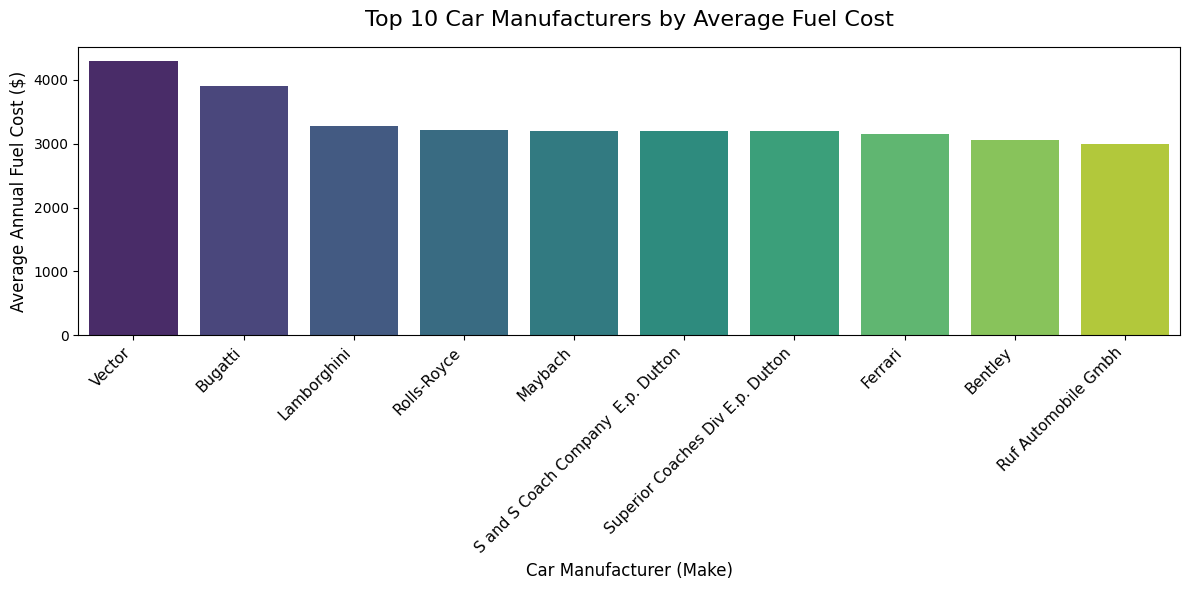

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_fuel_cost = X_train.groupby('make')['fuelCost08'].mean().sort_values(ascending=False).head(10)

top_10_df = top_10_fuel_cost.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=top_10_df, x='make', y='fuelCost08', hue='make', dodge=False, palette='viridis')

plt.title('Top 10 Car Manufacturers by Average Fuel Cost', fontsize=16, pad=15)
plt.xlabel('Car Manufacturer (Make)', fontsize=12)
plt.ylabel('Average Annual Fuel Cost ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

### Outliers

In [37]:
make_counts = X_train['make'].value_counts()

threshold = 3

outliers_make = make_counts[make_counts <= threshold]

print(f"There are {len(outliers_make)} manufacturers with exactly {threshold} vehicle in the dataset.")
print("\nList of these manufacturers:")

print(outliers_make.index.tolist())

There are 35 manufacturers with exactly 3 vehicle in the dataset.

List of these manufacturers:
['Saleen', 'Morgan', 'Yugo', 'BMW Alpina', 'Vector', 'Panther Car Company Limited', 'Avanti Motor Corporation', 'Quantum Technologies', 'Ruf Automobile Gmbh', 'Sterling', 'Azure Dynamics', 'CODA Automotive', 'SRT', 'Mobility Ventures LLC', 'Pagani', 'E. P. Dutton, Inc.', 'PAS, Inc', 'Panoz Auto-Development', 'Qvale', 'Lambda Control Systems', 'London Coach Co Inc', 'Shelby', 'Import Foreign Auto Sales Inc', 'S and S Coach Company  E.p. Dutton', 'Superior Coaches Div E.p. Dutton', 'Vixen Motor Company', 'Volga Associated Automobile', 'Panos', 'London Taxi', 'Red Shift Ltd.', 'Excalibur Autos', 'Mahindra', 'Fisker', 'ASC Incorporated', 'CCC Engineering']


In [38]:
# Remove them from train
X_train = X_train[~X_train['make'].isin(outliers_make.index)]

print(f"New number of rows in train set: {len(X_train)}")

X_test = X_test[~X_test['make'].isin(outliers_make.index)]


New number of rows in train set: 29946


### Bar Chart based on fuel type

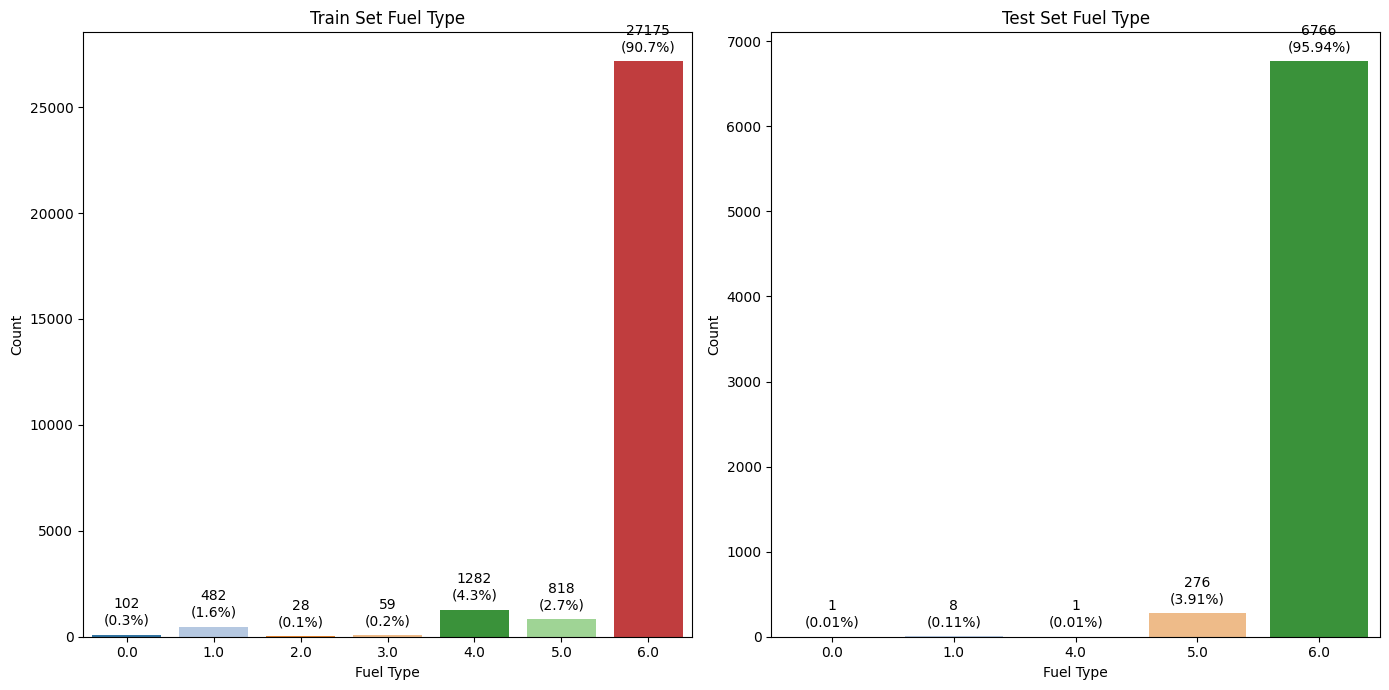

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Train Set 
ax0 = sns.countplot(
    data=X_train,
    x='fuel',
    hue='fuel',
    ax=axes[0],
    palette="tab20",
    legend=False
)

total_train = len(X_train)

for p in ax0.patches:
    height = p.get_height()
    if height > 0:
        ax0.annotate(
            f'{int(height)}\n({height / total_train * 100:.1f}%)', 
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0, 5), 
            textcoords='offset points'
        )

axes[0].set_title('Train Set Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Count')

# Test Set 
ax1 = sns.countplot(
    data=X_test,
    x='fuel',
    hue='fuel',
    ax=axes[1],
    palette="tab20",
    legend=False
)

total_test = len(X_test)

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
            f'{int(height)}\n({height / total_test * 100:.2f}%)',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0, 5),
            textcoords='offset points'
        )

axes[1].set_title('Test Set Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Since our goal is to predict the fuelCost08 variable for the entries in the test set, we get rid of CNG and Bifuel vehicles that are present only in the train set. Moreover the electric, hybrid and flexible-fuel cars represent a super small percentage.

In [40]:
print(len(X_train))
X_train = X_train[X_train['fuel'] != 'CNG']
X_train = X_train[X_train['fuel'] != 'Bifuel']
print(len(X_train))

29946
29946


### Division based on manufacturing year

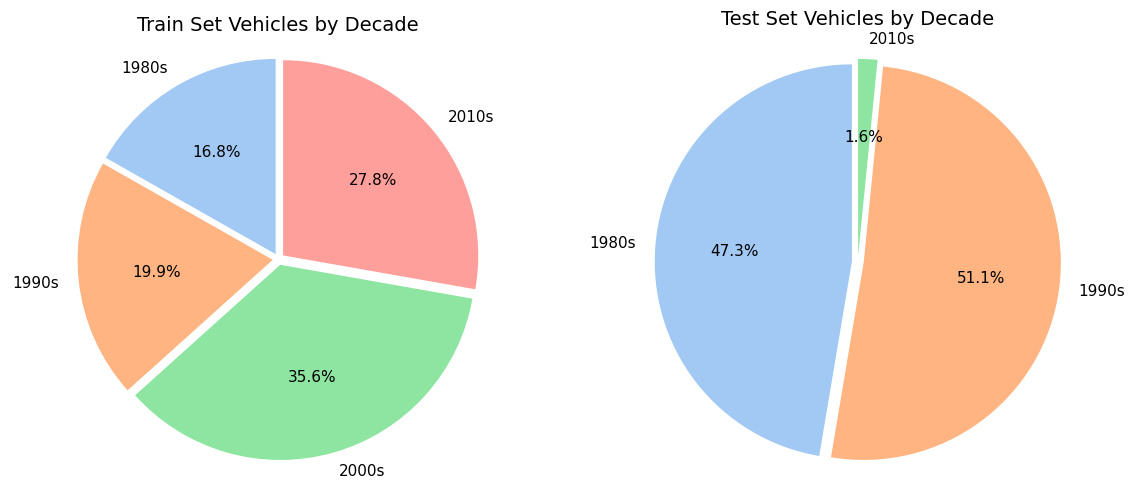

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Train
decades_train = (X_train['year'] // 10) * 10
decade_counts_train = decades_train.value_counts().sort_index()
labels_train = [f"{int(decade)}s" for decade in decade_counts_train.index]

colors = sns.color_palette('pastel', n_colors=max(len(decade_counts_train), 1))
explode_train = [0.03] * len(decade_counts_train)

axes[0].pie(
    decade_counts_train,
    labels=labels_train,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(decade_counts_train)],
    explode=explode_train,
    textprops={'fontsize': 11}
)
axes[0].set_title('Train Set Vehicles by Decade', fontsize=14)
axes[0].axis('equal')


# Test
decades_test = (X_test['year'] // 10) * 10
decade_counts_test = decades_test.value_counts().sort_index()
labels_test = [f"{int(decade)}s" for decade in decade_counts_test.index]

explode_test = [0.03] * len(decade_counts_test)

axes[1].pie(
    decade_counts_test,
    labels=labels_test,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(decade_counts_test)],
    explode=explode_test,
    textprops={'fontsize': 11}
)
axes[1].set_title('Test Set Vehicles by Decade', fontsize=14, pad=10)
axes[1].axis('equal')


plt.tight_layout()
plt.show()

### Division per number of cylinders

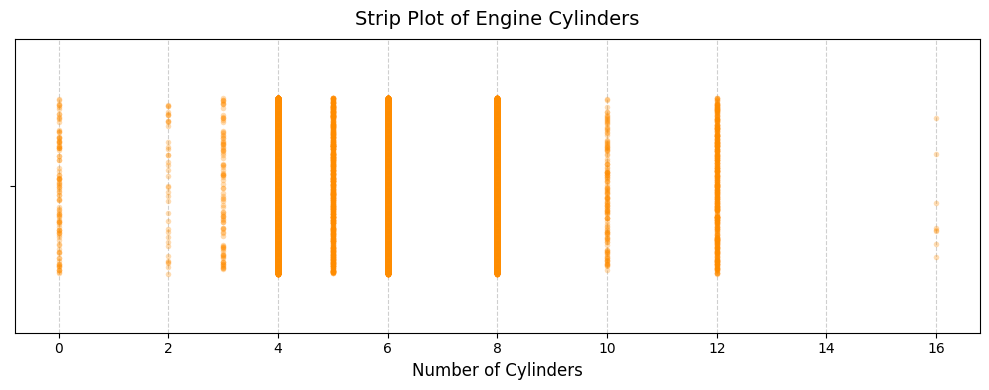

In [42]:
plt.figure(figsize=(10, 4))

sns.stripplot(x=X_train['cylinders'], color='darkorange', alpha=0.3, jitter=0.3, size=4)

plt.title('Strip Plot of Engine Cylinders', fontsize=14, pad=10)
plt.xlabel('Number of Cylinders', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Train Set:
Outliers: 113
Anomalous cylinders: [np.float64(0.0), np.float64(16.0)]
Test Set:
Outliers: 66
Anomalous cylinders: [np.float64(0.0), np.float64(2.0), np.float64(12.0)]


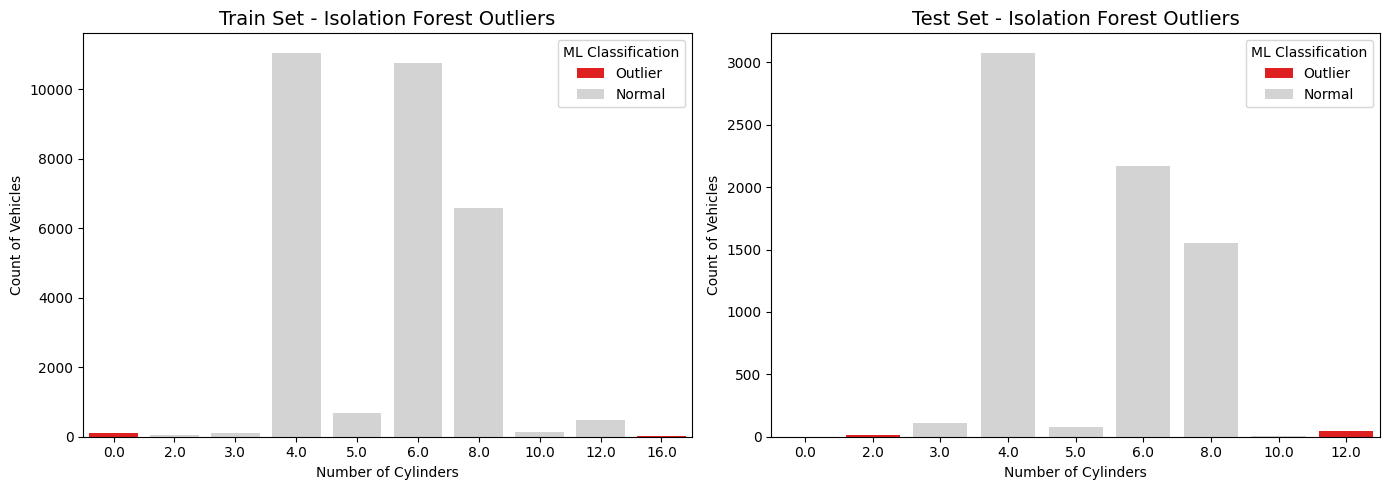

In [43]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
df_train_clean = X_train.dropna(subset=['cylinders']).copy()

iso_forest_train = IsolationForest(contamination=0.01, random_state=42)
df_train_clean['anomaly_label'] = iso_forest_train.fit_predict(df_train_clean[['cylinders']])

outliers_train = df_train_clean[df_train_clean['anomaly_label'] == -1]

print("Train Set:")
print(f"Outliers: {len(outliers_train)}")
print(f"Anomalous cylinders: {sorted(outliers_train['cylinders'].unique())}")

sns.countplot(
    data=df_train_clean, 
    x='cylinders', 
    hue='anomaly_label', 
    palette={1: 'lightgray', -1: 'red'},
    ax=axes[0]
)

axes[0].set_title('Train Set - Isolation Forest Outliers', fontsize=14)
axes[0].set_xlabel('Number of Cylinders')
axes[0].set_ylabel('Count of Vehicles')
axes[0].legend(title='ML Classification', labels=['Outlier', 'Normal'])


# Test
df_test_clean = X_test.dropna(subset=['cylinders']).copy()

iso_forest_test = IsolationForest(contamination=0.01, random_state=42)
df_test_clean['anomaly_label'] = iso_forest_test.fit_predict(df_test_clean[['cylinders']])

outliers_test = df_test_clean[df_test_clean['anomaly_label'] == -1]

print("Test Set:")
print(f"Outliers: {len(outliers_test)}")
print(f"Anomalous cylinders: {sorted(outliers_test['cylinders'].unique())}")

sns.countplot(
    data=df_test_clean, 
    x='cylinders', 
    hue='anomaly_label', 
    palette={1: 'lightgray', -1: 'red'},
    ax=axes[1]
)

axes[1].set_title('Test Set - Isolation Forest Outliers', fontsize=14)
axes[1].set_xlabel('Number of Cylinders')
axes[1].set_ylabel('Count of Vehicles')
axes[1].legend(title='ML Classification', labels=['Outlier', 'Normal'])


plt.tight_layout()
plt.show()

In the test set the 2-cylinders and 12-cylinders cars are less so they look like outliers but actually they must not be considered as such because they are not outliers in the train

Let's see the outliers

In [44]:
outliers_train[['make', 'model', 'year', 'cylinders']]

,make,model,year,cylinders
7138,Nissan,Altra EV,2000,0.0
7139,Toyota,RAV4 EV,2000,0.0
8143,Toyota,RAV4 EV,2001,0.0
8144,Ford,Th!nk,2001,0.0
8146,Ford,Explorer USPS Electric,2001,0.0
8147,Nissan,Hyper-Mini,2001,0.0
9212,Toyota,RAV4 EV,2002,0.0
9213,Ford,Explorer USPS Electric,2002,0.0
10329,Toyota,RAV4 EV,2003,0.0
14063,Bugatti,Veyron,2006,16.0


They all belong to the same car model which has 16 cylinders so since it is a specific model we can drop it.

In [45]:
print(f"Original dataset size: {X_train.shape}")

X_train = X_train.drop(index=outliers_train.index)

print(f"Cleaned dataset size: {X_train.shape}")

print(f"Remaining cylinder types: {sorted(X_train['cylinders'].dropna().unique())}")

Original dataset size: (29946, 49)
Cleaned dataset size: (29833, 49)
Remaining cylinder types: [np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0)]


### Vehicle Size Distribution

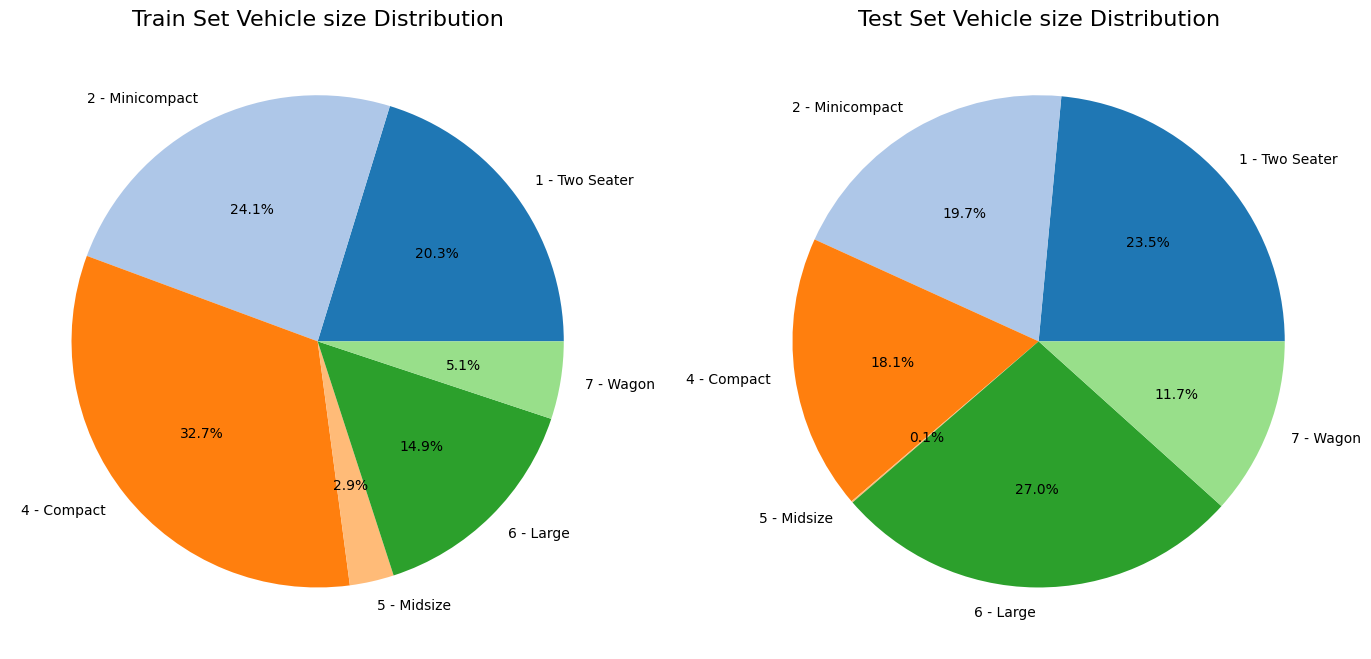

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

class_names = [
    'Two Seater', 'Minicompact', 'Subcompact', 'Compact', 'Midsize',
    'Large', 'Wagon', 'Sport Utility', 'Pickup', 'Van', 'Special Purpose'
]

# Train
counts_train = X_train['size'].value_counts().sort_index()
labels_train = [f"{int(v)} - {class_names[int(v)-1]}" for v in counts_train.index]

colors = sns.color_palette("tab20", len(class_names))

axes[0].pie(
    counts_train,
    labels=labels_train,
    autopct='%1.1f%%',
    colors=colors[:len(counts_train)]
)
axes[0].set_title('Train Set Vehicle size Distribution', fontsize=16)

# Set
counts_val = X_test['size'].value_counts().sort_index()
labels_val = [f"{int(v)} - {class_names[int(v)-1]}" for v in counts_val.index]

axes[1].pie(
    counts_val,
    labels=labels_val,
    autopct='%1.1f%%',
    colors=colors[:len(counts_val)]
)
axes[1].set_title('Test Set Vehicle size Distribution', fontsize=16)

plt.tight_layout()
plt.show()

## Utils 

In [47]:
def plot_distribution(df, name):
    
    numeric_cols = df.select_dtypes(include=np.number).columns


    if df.empty or len(numeric_cols) == 0:
        print(f"No numeric features to plot for '{name}' (empty dataset or no numeric columns).")
    else:
        n = len(numeric_cols)
        ncols = 4
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
            axes[i].set_title(col)

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f"Feature Distributions - {name}", y=1.02)
        plt.tight_layout()
        plt.show()

### Model Pipeline

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

def run_models(X_train, X_test, cols_to_transform, binary_cols, num_cols):

    print(f"Number of rows in train set: {len(X_train)}")
    print(f"Number of rows in test set: {len(X_test)}")

    important_columns = cols_to_transform + binary_cols + num_cols + ['fuelCost08']

    # Drop missing values
    X_train.dropna(subset=important_columns, inplace=True)
    X_test.dropna(subset=important_columns, inplace=True)

    print(f"Number of rows in train set: {len(X_train)}")
    print(f"Number of rows in test set: {len(X_test)}")

    # Separate target variable from training set
    y_train = X_train['fuelCost08'].copy()
    X_train.drop(columns=['fuelCost08'], inplace=True)

    # Separate target variable from testing set
    y_test = X_test['fuelCost08'].copy()
    X_test.drop(columns=['fuelCost08'], inplace=True)

    # Force all categorical columns to be strings to prevent mixed-type errors
    X_train[cols_to_transform] = X_train[cols_to_transform].astype(str)
    X_test[cols_to_transform] = X_test[cols_to_transform].astype(str)

    # Set up the ColumnTransformer with 3 distinct pipelines
    col_trans = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_transform),
        ('num_cont', StandardScaler(), num_cols), # Standardizes continuous numbers
        ('num_bin', 'passthrough', binary_cols)          # Leaves 0/1 flags exactly as they are
    ], verbose_feature_names_out=False)

    # Transform training data
    X_train = col_trans.fit_transform(X_train).astype(float)

    # Transform testing data
    X_test = col_trans.transform(X_test).astype(float)
    print(f"Number of rows in test set transformed: {len(X_test)}")

    # Linear Regression
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)

    print("\nLinear Regression")
    print("Train R2:", lin_reg.score(X_train, y_train))
    print("Test R2:", lin_reg.score(X_test, y_test))

    # SVM
    svm = SVR(kernel='linear', C=1.5, epsilon=0.05)
    svm.fit(X_train, y_train)

    print("\nSVM")
    print("Train R2:", svm.score(X_train, y_train))
    print("Test R2:", svm.score(X_test, y_test))

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    print("\nRandom Forest")
    print("Train R2:", rf.score(X_train, y_train))
    print("Test R2:", rf.score(X_test, y_test))

    return lin_reg, svm, rf

## Models for All Cars

In [49]:
X_test.head(5)

,charge240,cityA08,cityA08U,cityE,cityUF,co2TailpipeAGpm,combA08,combA08U,combE,combinedUF,cylinders,displ,fuelCost08,fuelCostA08,highwayA08,highwayA08U,highwayE,highwayUF,make,model,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCityA,UHighwayA,year,rangeA,evMotor,startStop,phevCity,phevHwy,phevComb,total_interior_volume,automatic,numOfGears,is_front,is_rear,size,premium,fuel
0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,6.0,4.3,2000,0,0,0.0,0.0,0.0,GMC,R15 Pickup 2WD,0,0.0,0.0,0.0,0.0,0.0,0.0,1987,NaN,NaN,0.0,0,0,0,0,1,3.0,0,1,6,0,6.0
1,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,3.0,1.2,900,0,0,0.0,0.0,0.0,Mitsubishi,Mirage,0,0.0,0.0,0.0,0.0,0.0,0.0,2017,NaN,NaN,0.0,0,0,0,206,0,5.0,1,0,2,0,6.0
2,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,3.0,1.2,800,0,0,0.0,0.0,0.0,Mitsubishi,Mirage,0,0.0,0.0,0.0,0.0,0.0,0.0,2017,NaN,NaN,0.0,0,0,0,206,2,10.0,1,0,2,0,6.0
3,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,6.0,3.6,1450,0,0,0.0,0.0,0.0,Chrysler,Pacifica,0,0.0,0.0,0.0,0.0,0.0,0.0,2017,NaN,NaN,0.0,0,0,0,0,1,9.0,1,0,5,0,6.0
4,7.0,0,0.0,28.0,0.0,0.0,0,0.0,30.0,0.0,0.0,NaN,600,0,0,0.0,33.0,0.0,Mitsubishi,i-MiEV,59,63.9,0.0,54.0,0.0,0.0,0.0,2017,NaN,49 kW DCPM,0.0,0,0,0,98,1,1.0,0,1,1,0,0.0


### Column transformations

In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print(f"Number of rows in train set: {len(X_train)}")
print(f"Number of rows in test set: {len(X_test)}")

# Categorical columns to One-Hot Encode
cols_to_transform = []

# Binary columns 
binary_cols = ['premium', 'automatic', 'is_front', 'is_rear', 'startStop']

# Numerical columns to Standardize
continuous_cols = ['cylinders', 'year', 'numOfGears', 'size'] 

important_columns = cols_to_transform + binary_cols + continuous_cols + ['fuelCost08']

# Drop missing values
X_train.dropna(subset=important_columns, inplace=True)

X_test_transformed = X_test.copy()
X_test_transformed.dropna(subset=important_columns, inplace=True)

print(f"Number of rows in train set: {len(X_train)}")
print(f"Number of rows in test set: {len(X_test_transformed)}")

# Separate target variable from training set
y_train = X_train['fuelCost08'].copy()
X_train.drop(columns=['fuelCost08'], inplace=True)

# Separate target variable from testing set
y_test = X_test_transformed['fuelCost08'].copy()
X_test_transformed.drop(columns=['fuelCost08'], inplace=True)

# Force all categorical columns to be strings to prevent mixed-type errors
X_train[cols_to_transform] = X_train[cols_to_transform].astype(str)
X_test_transformed[cols_to_transform] = X_test_transformed[cols_to_transform].astype(str)

# Set up the ColumnTransformer with 3 distinct pipelines
col_trans = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_transform),
    ('num_cont', StandardScaler(), continuous_cols),
    ('num_bin', 'passthrough', binary_cols)          
], verbose_feature_names_out=False)

# Transform training data
X_train = col_trans.fit_transform(X_train).astype(float)

# Transform testing data
X_test_transformed = col_trans.transform(X_test_transformed).astype(float)
print(f"Number of rows in test set transformed: {len(X_test_transformed)}")

Number of rows in train set: 29833
Number of rows in test set: 7052
Number of rows in train set: 29833
Number of rows in test set: 7052
Number of rows in test set transformed: 7052


### Linear Regression

In [51]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
# Check how well it performs on unseen test data
print(lin_reg.score(X_train, y_train))
print(lin_reg.score(X_test_transformed, y_test))

0.7835714701402892
0.7201763306781658


### Explainability for Linear Regression

/opt/anaconda3/envs/da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ExactExplainer explainer: 7053it [00:12, 158.71it/s]                          


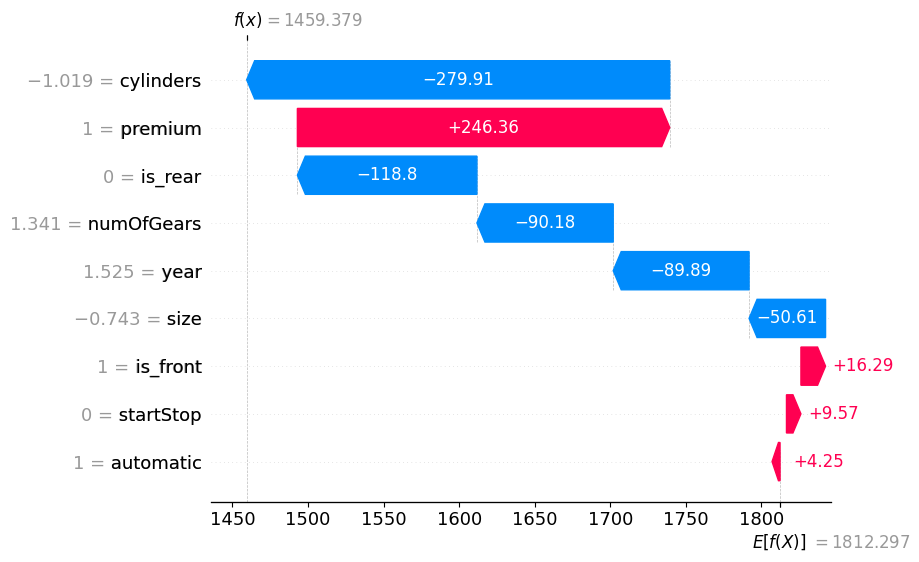

In [53]:
import shap as sh 

explainer = sh.Explainer(lin_reg.predict, sh.utils.sample(X_train, 100))
shap_values = explainer(X_test_transformed)
shap_values.feature_names = col_trans.get_feature_names_out().tolist()

sh.plots.waterfall(shap_values[15])


### SVM

In [54]:
from sklearn.svm import SVR

svm = SVR(kernel='linear', C=1.5, epsilon=0.05)
svm.fit(X_train, y_train)

# Check how well it performs on unseen test data
print(svm.score(X_train, y_train))
print(svm.score(X_test_transformed, y_test))


0.7779194042030256
0.7112136223716048


### Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_transformed)

rf_train_score = rf_model.score(X_train, y_train)
print(f"Random Forest Training R-squared: {rf_train_score:.4f}")

# Check how well it performs on unseen test data
rf_test_score = rf_model.score(X_test_transformed, y_test)
print(f"Random Forest Test R-squared: {rf_test_score:.4f}")

Random Forest Training R-squared: 0.8862
Random Forest Test R-squared: 0.7507


## Fuel specific models

### Gas Cars

In [56]:
gas_cars.head(5)

,cylinders,displ,fuelCost08,make,model,year,startStop,total_interior_volume,automatic,numOfGears,is_front,is_rear,size,premium
0,4.0,2.0,1550,Alfa Romeo,Spider Veloce 2000,1985,0.0,0,0,5.0,0,1,1,0
1,12.0,4.9,2900,Ferrari,Testarossa,1985,0.0,0,0,5.0,0,1,1,0
2,4.0,2.2,1200,Dodge,Charger,1985,0.0,96,0,5.0,1,0,1,0
3,8.0,5.2,2900,Dodge,B150/B250 Wagon 2WD,1985,0.0,0,1,3.0,0,1,6,0
4,4.0,2.2,2050,Subaru,Legacy AWD Turbo,1993,0.0,104,0,5.0,1,1,2,1


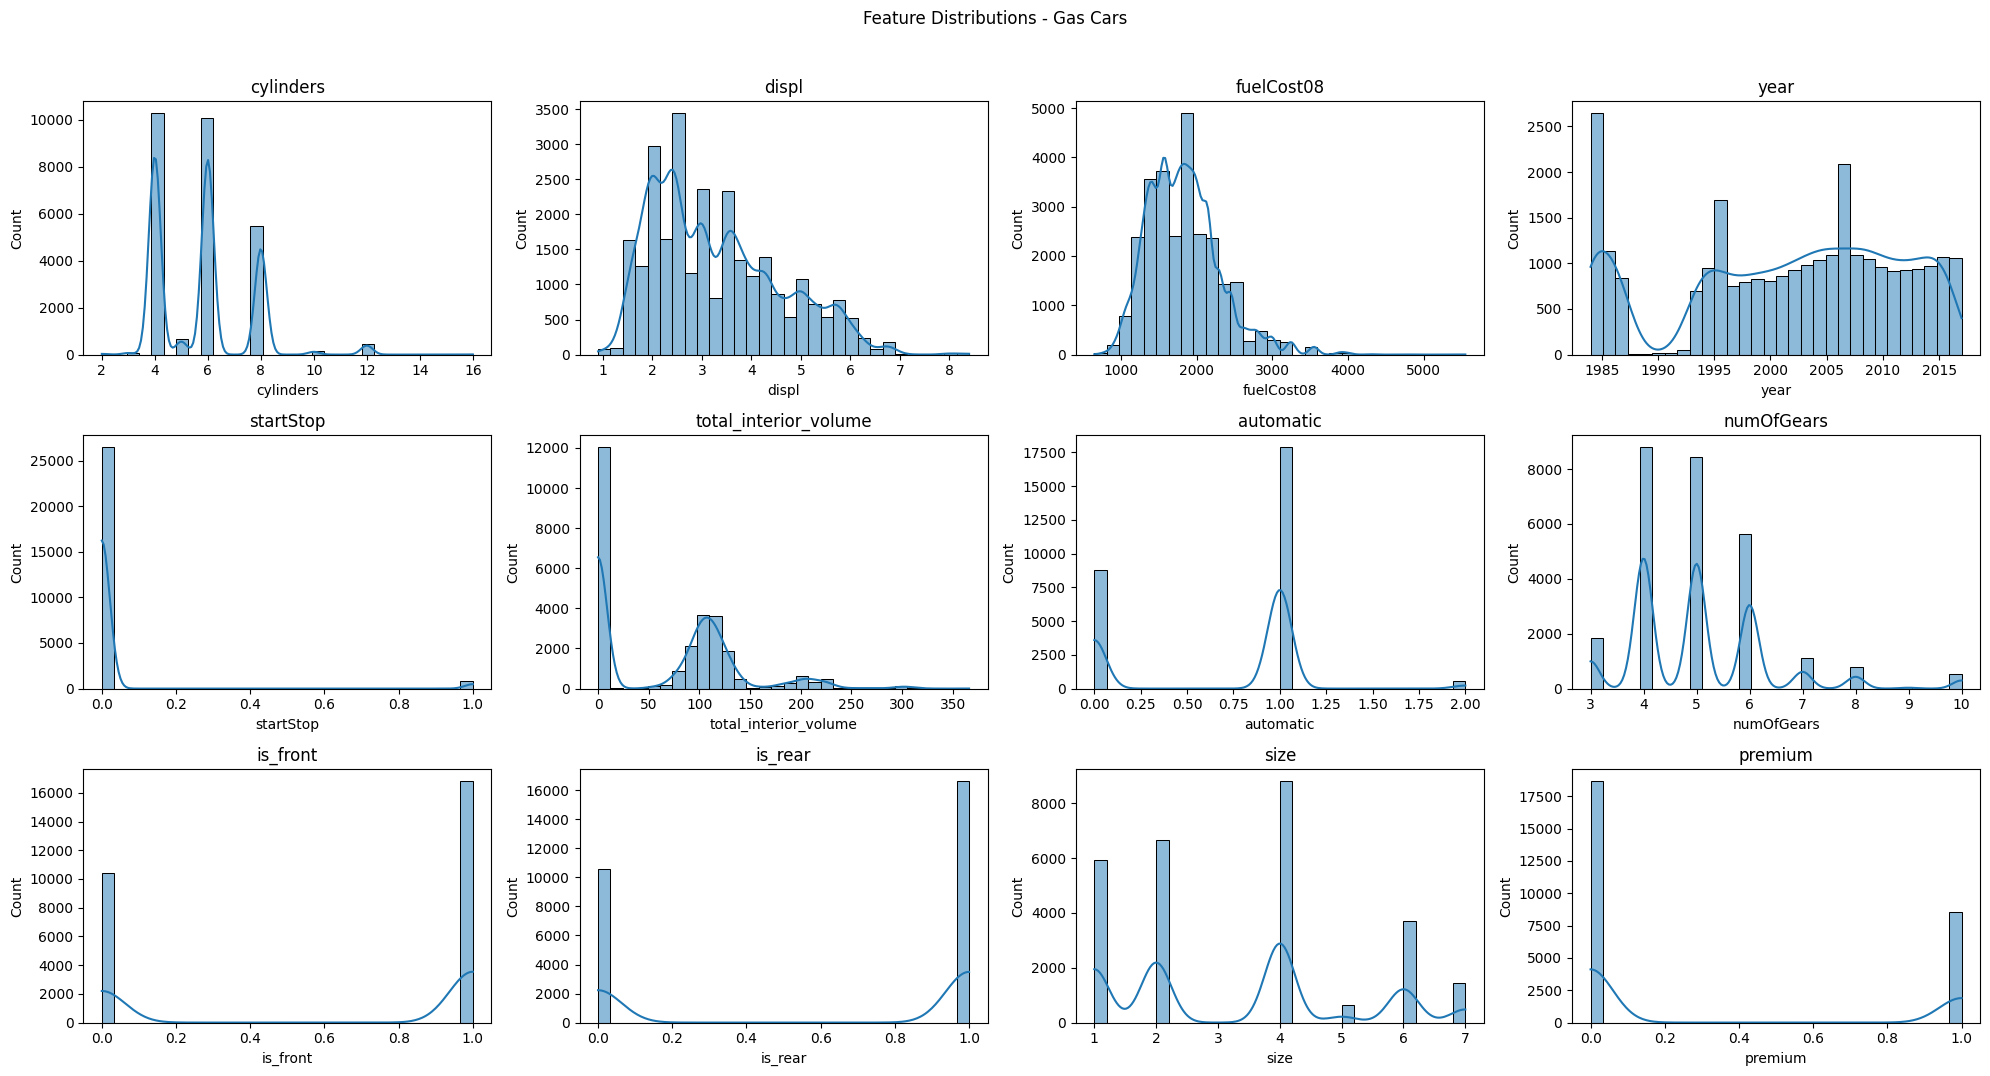

In [57]:
plot_distribution(gas_cars, "Gas Cars")

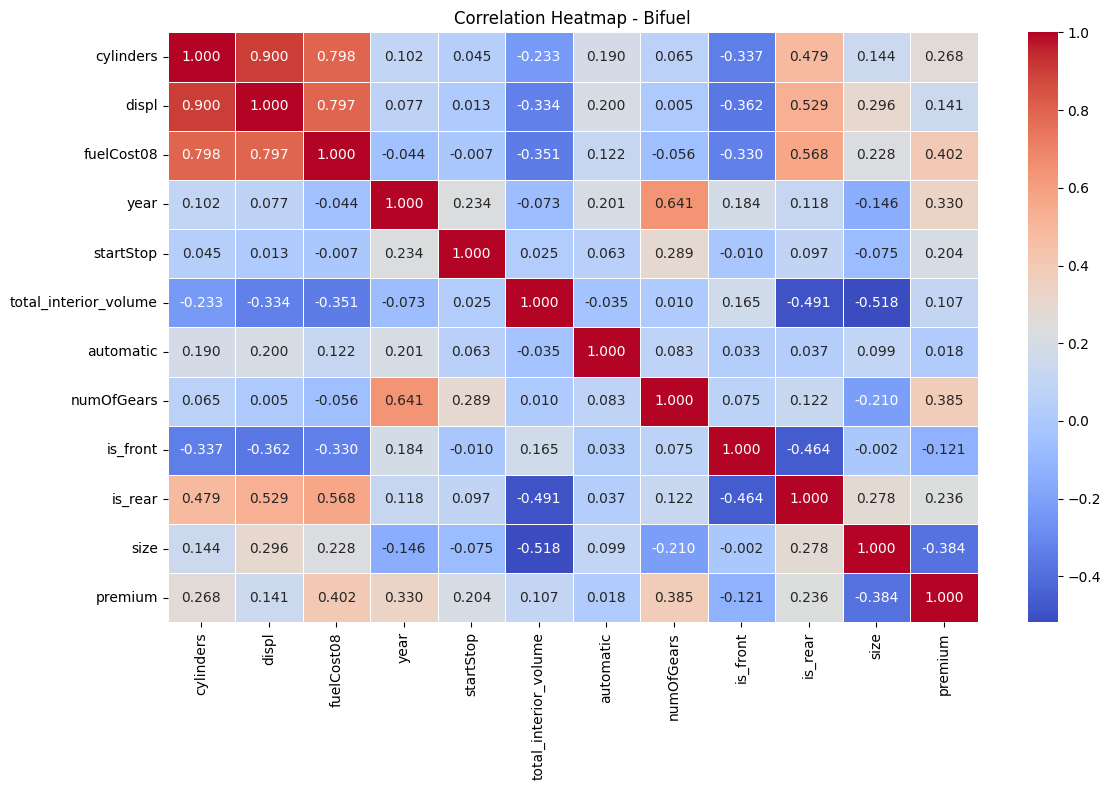

In [58]:
numeric_cols = gas_cars.select_dtypes(include=np.number).columns

if gas_cars.empty or len(numeric_cols) < 2:
    print(f"Cannot plot correlation heatmap for '{name}': not enough numeric data.")
else:
    corr = gas_cars[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.5, fmt='.3f', annot=True)
    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

In [59]:
# Drop columns with very high pairwise correlation (|corr| >= 0.99)
corr_matrix = gas_cars[numeric_cols].corr().abs()

# Keep only upper triangle of correlation matrix (without diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop
high_corr_cols = [col for col in upper.columns if (upper[col] >= 0.95).any()]

print(f"Columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

# Drop from gas_cars
gas_cars.drop(columns=high_corr_cols, inplace=True)
gas_cars_test.drop(columns=high_corr_cols, inplace=True)

# Refresh numeric_cols after dropping
numeric_cols = gas_cars.select_dtypes(include=np.number).columns
print(f"Remaining numeric columns: {len(numeric_cols)}")

Columns to drop (0): []
Remaining numeric columns: 12


In [60]:
print(gas_cars.columns)
print(gas_cars_test.columns)

Index(['cylinders', 'displ', 'fuelCost08', 'make', 'model', 'year',
       'startStop', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'size', 'premium'],
      dtype='str')
Index(['cylinders', 'displ', 'fuelCost08', 'make', 'model', 'year',
       'startStop', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'size', 'premium'],
      dtype='str')


In [61]:
num_cols_gas = []

bin_cols_gas = ['automatic', 'premium', 'is_front', 'is_rear', 'startStop']

cols_to_transform_gas = ['cylinders', 'year', 'size','numOfGears']

lin_gas, svm_gas, rf_gas = run_models(gas_cars, gas_cars_test, num_cols=num_cols_gas, binary_cols=bin_cols_gas, cols_to_transform=cols_to_transform_gas)

Number of rows in train set: 27220
Number of rows in test set: 6791
Number of rows in train set: 27217
Number of rows in test set: 6791
Number of rows in test set transformed: 6791

Linear Regression
Train R2: 0.8117942226732187
Test R2: 0.6217424363921837

SVM
Train R2: 0.7738552993297796
Test R2: 0.7052396382273685

Random Forest
Train R2: 0.8975683955227247
Test R2: 0.7942990607842441


### Diesel Cars


In [62]:
diesel_cars.head(5)

,cylinders,displ,fuelCost08,make,model,year,startStop,total_interior_volume,automatic,numOfGears,is_front,is_rear,size
141,6.0,3.5,1700,Mercedes-Benz,300SD,1993,0.0,124,1,4.0,0,1,2
213,8.0,6.2,1800,GMC,G15/25 Rally 2WD,1985,0.0,0,1,4.0,0,1,6
225,8.0,6.2,1900,GMC,G15/25 Rally 2WD,1985,0.0,0,0,4.0,0,1,6
372,8.0,6.2,1900,Chevrolet,K1500 Pickup 4WD,1993,0.0,0,1,4.0,1,1,6
382,8.0,6.2,1900,Chevrolet,Pickup 2500 4WD,1993,0.0,0,1,4.0,1,1,6


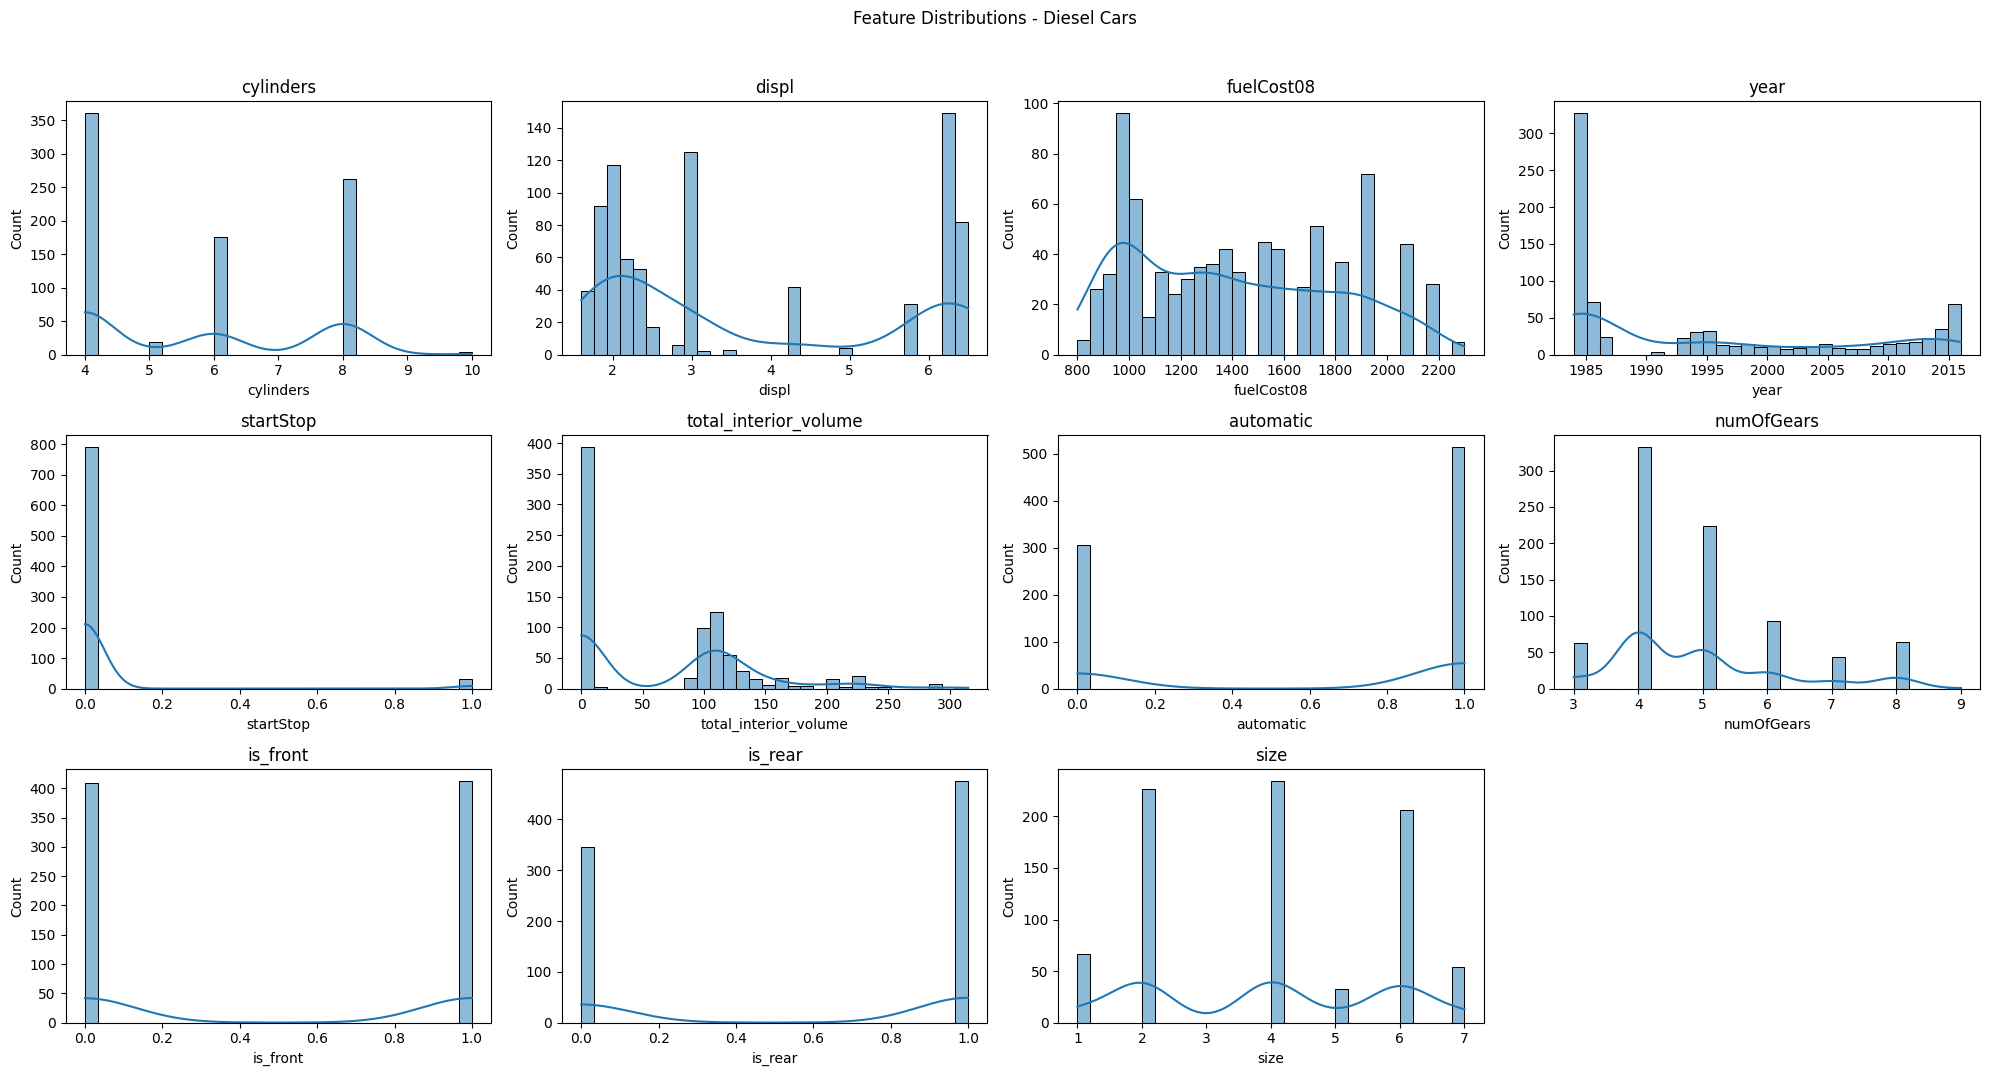

In [63]:
plot_distribution(diesel_cars, "Diesel Cars")

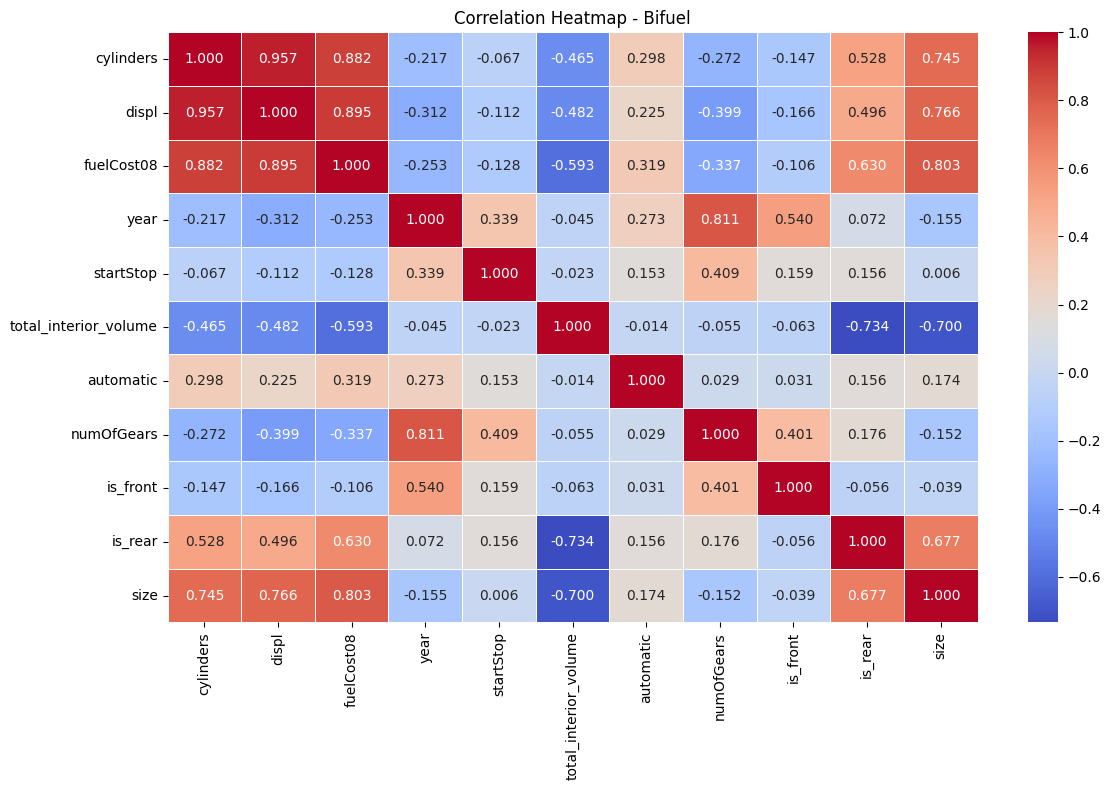

In [64]:
numeric_cols = diesel_cars.select_dtypes(include=np.number).columns

if diesel_cars.empty or len(numeric_cols) < 2:
    print(f"Cannot plot correlation heatmap for '{name}': not enough numeric data.")
else:
    corr = diesel_cars[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.5, fmt='.3f', annot=True)
    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

In [65]:
# Drop columns with very high pairwise correlation (|corr| >= 0.99)
corr_matrix = diesel_cars[numeric_cols].corr().abs()

# Keep only upper triangle of correlation matrix (without diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop
high_corr_cols = [col for col in upper.columns if (upper[col] >= 0.95).any()]

print(f"Columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

# Drop from diesel_cars
diesel_cars.drop(columns=high_corr_cols, inplace=True)
diesel_cars_test.drop(columns=high_corr_cols, inplace=True)

# Refresh numeric_cols after dropping
numeric_cols = diesel_cars.select_dtypes(include=np.number).columns
print(f"Remaining numeric columns: {len(numeric_cols)}")

Columns to drop (1): ['displ']
Remaining numeric columns: 10


In [66]:
print(diesel_cars.columns)
print(diesel_cars_test.columns)

Index(['cylinders', 'fuelCost08', 'make', 'model', 'year', 'startStop',
       'total_interior_volume', 'automatic', 'numOfGears', 'is_front',
       'is_rear', 'size'],
      dtype='str')
Index(['cylinders', 'fuelCost08', 'make', 'model', 'year',
       'total_interior_volume', 'automatic', 'numOfGears', 'is_front',
       'is_rear', 'size'],
      dtype='str')


In [67]:
cols_to_transform_diesel = []

bin_cols_diesel = ['automatic', 'is_front', 'is_rear']

num_cols_diesel = ['cylinders', 'size', 'year', 'numOfGears']

lin_diesel, svm_diesel, rf_diesel = run_models(diesel_cars, diesel_cars_test, num_cols=num_cols_diesel, binary_cols=bin_cols_diesel, cols_to_transform=cols_to_transform_diesel)

Number of rows in train set: 821
Number of rows in test set: 276
Number of rows in train set: 821
Number of rows in test set: 276
Number of rows in test set transformed: 276

Linear Regression
Train R2: 0.8799685852285999
Test R2: 0.8410249206837593

SVM
Train R2: 0.8585348924120484
Test R2: 0.841698480128734

Random Forest
Train R2: 0.9760899391463923
Test R2: 0.8831230808883401


Since in the test set we have only 1 occurrence for hybrid, electric and FFV car, it is meaningless to build a model specific for each of these and then test it on a single entry.

### EV Cars

In [68]:
ev_cars.columns

Index(['charge240', 'cityE', 'combE', 'fuelCost08', 'highwayE', 'make',
       'model', 'range', 'rangeCity', 'rangeHwy', 'year', 'evMotor',
       'charge240b', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'size'],
      dtype='str')

We drop columns `cityE`, `highwayE` since we have a column combining both columns `combE`. We do the same for columns `rangeCity` and `rangeHwy`.

In [69]:
ev_cars.drop(columns=['cityE', 'highwayE', 'rangeCity', 'rangeHwy'], inplace=True)
#ev_cars_test.drop(columns=['cityE', 'highwayE', 'rangeCity', 'rangeHwy'], inplace=True)

We can extract how powerful the engine actually is, so we do that and after that we drop the `evMotor` column.

In [70]:
def handle_ev_motor(ev_motor: pd.DataFrame) -> int: 
	"""
	@brief Auxiliary funtion which determines the power of the EV. It either extracts the power directly, 
		   or it sums the power of all the engines the EV has.
	@param ev_motor specification of EV engine

	@return power of the car
	"""
	if pd.isna(ev_motor) or ev_motor == None:
		return -1
	elif re.match(r'(\d+ \(front\) \d+ \(rear\))|(\d+ and \d+)', ev_motor):
		powers_of_motors = re.findall(r"(\d+)", ev_motor)
		return int(powers_of_motors[0]) + int(powers_of_motors[1])
	else:
		return int(re.findall(r"(\d+)", ev_motor)[0])


def get_engine_power(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Extracts the EV engine power which is located in the evMotor attribute, stores it in a dedicated "power" column 
		   and after that it deletes the evMotor column.
    
    @param df input dataframe
    @return modified dataframe
    """
	
    df['power'] = df['evMotor'].apply(handle_ev_motor)
    df.drop(columns=['evMotor'], inplace=True)
	
    return df

ev_cars = get_engine_power(ev_cars)
#ev_cars_test = get_engine_power(ev_cars_test)

### Ensemble Model 
We create an ensemble model that uses one model for diesel cars trained on diesel cars and another for the rest of the cars trained on gas_cars. Since in the test set there is only one instance of a ffv vehicle, one instance of an hybrid vehicle and one instance of an electric vehicle,it doesn't make sense to create a model for them because we cannot validate it and therefore we use the model gotten from gas cars to make inference on those three samples.

In [71]:
from sklearn.metrics import r2_score

def ensemble_model(gas_model, diesel_model, X, y):
    """
    @brief A simple ensemble model which combines predictions of gas, diesel and ev models by averaging their predictions.
           It uses the fuelType column to determine which model's prediction should be used for each row.

    @param gas_model trained model for gas cars
    @param diesel_model trained model for diesel cars
    @param ev_model trained model for electric cars
    @param X input features for which we want to make predictions

    @return array of predictions
    """
    gas_mask = X['fuel'] != 'Diesel'
    diesel_mask = X['fuel'] == 'Diesel'

    predictions = np.zeros(len(X))

    if gas_mask.any():
        predictions[gas_mask] = gas_model.predict(X[gas_mask])
    
    if diesel_mask.any():
        predictions[diesel_mask] = diesel_model.predict(X[diesel_mask])
        
    r2 = r2_score(y, predictions)
    
    return predictions, r2

In [ ]:
ensemble_model_predictions, r2 = ensemble_model(rf_gas, rf_diesel, X_test, y_test)